6.77252845208234
monthe
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_id, dtype: int64


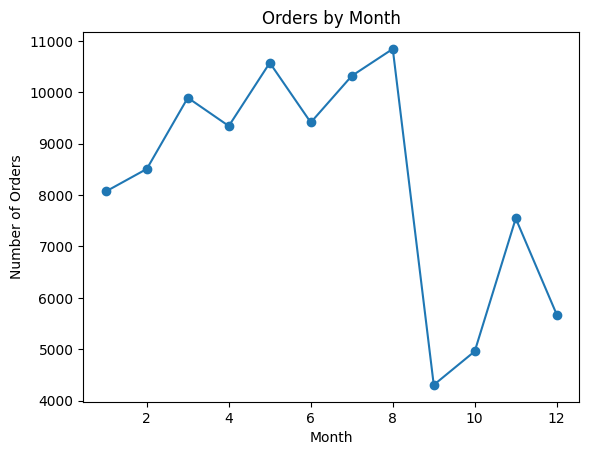

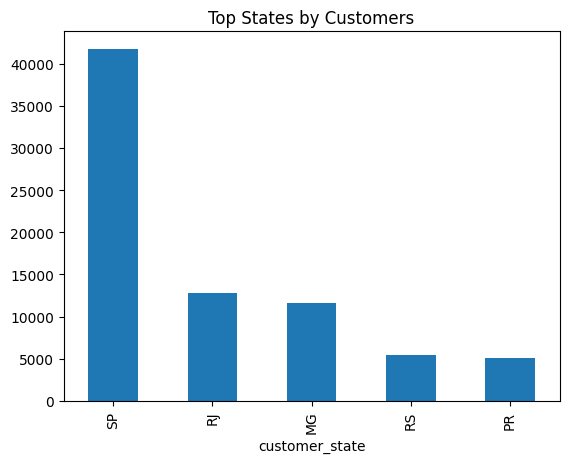

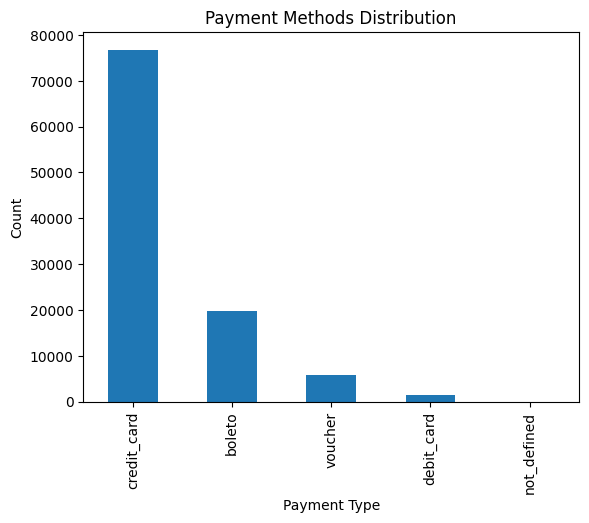

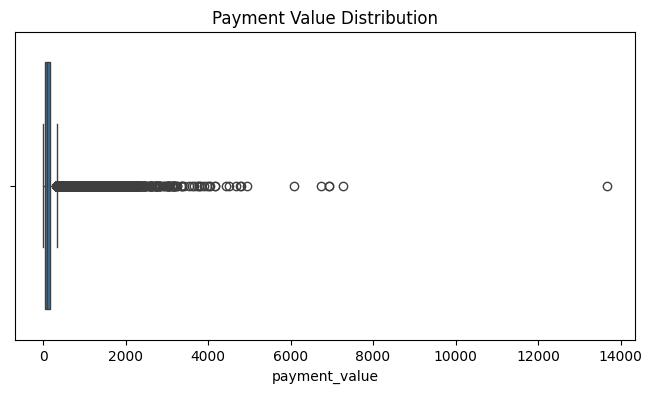

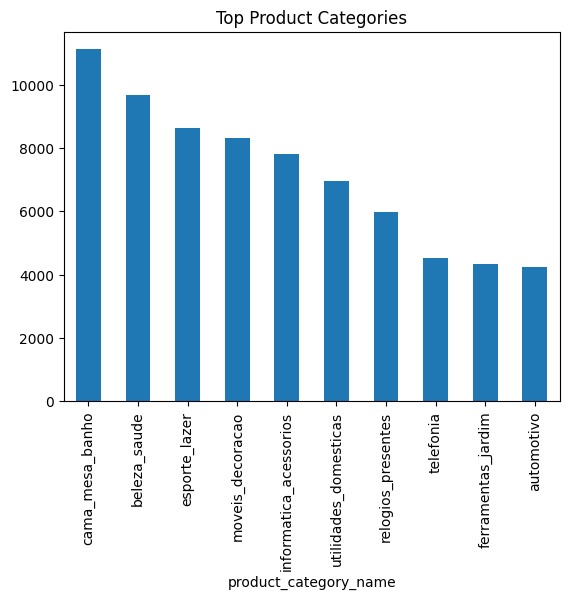

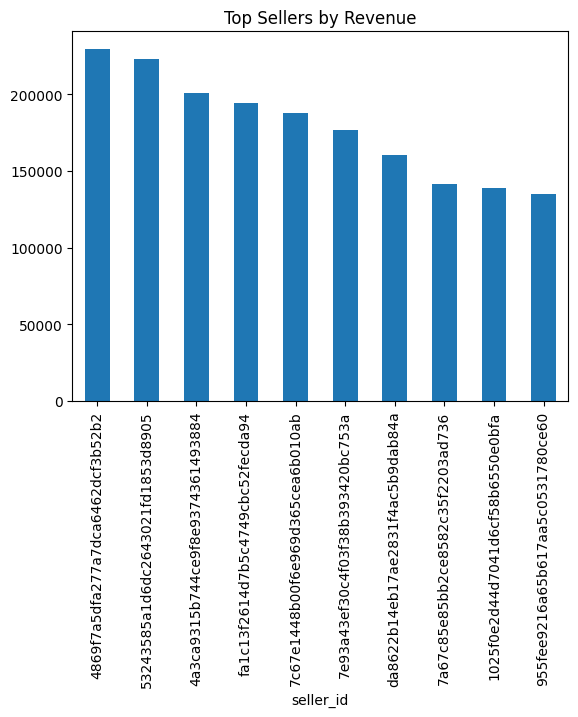

In [ ]:

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
orders=pd.read_csv("olist_orders_dataset.csv")
customers=pd.read_csv("olist_customers_dataset.csv")
order_items=pd.read_csv("olist_order_items_dataset.csv")
payments=pd.read_csv("olist_order_payments_dataset.csv")
products=pd.read_csv("olist_products_dataset.csv")
sellers=pd.read_csv("olist_sellers_dataset.csv")
## مدي توزيع حالات الطلبات 
orders["order_status"].value_counts()

## متوسط مده التوصيل  



date_time=[
    "order_purchase_timestamp",       
    "order_approved_at",               
   "order_delivered_carrier_date",   
   "order_delivered_customer_date",  
   "order_estimated_delivery_date"
]
for col in date_time:
    orders[col]=pd.to_datetime(orders[col])

  
## متوسط مده التوصيل 
orders["delivery_days"]=(
    orders["order_delivered_customer_date"]
    -
    orders ["order_purchase_timestamp"]


).dt.days


orders["delivery_days"].describe()


## ما نسبه الطلبات المتاخره 

delivered_days=orders[
    orders["order_status"] == "delivered"
]
delivered_days["delay_days"]=(
    orders["order_delivered_customer_date"]
    -orders["order_estimated_delivery_date"]

).dt.days
 
orders

late_orders=delivered_days[
    delivered_days["delay_days"] > 0

]

late_percentage=(
    late_orders.shape[0]
    /
    delivered_days.shape[0] 
    
)*100

print(late_percentage)



  

## بلغت نسبة الطلبات المتأخرة عن الموعد المتوقع 6.77% فقط، مما يشير إلى أداء جيد نسبيًا في عمليات التوصيل والتزام الشركة بمواعيد التسليم.


##ما عدد الطلبات في كل شهر وما الشهر الزي سجل عدد اكبر من الطلبات 

orders["monthe"]=orders["order_purchase_timestamp"].dt.month

monthly_orders=orders.groupby("monthe")["order_id"].count()
print(monthly_orders)

monthly_orders.plot(
    kind="line",
    marker="o"
)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()
##سجل شهر أغسطس أعلى عدد من الطلبات بإجمالي 10,843 طلبًا، بينما سجل شهر سبتمبر أقل عدد من الطلبات. كما يظهر وجود زيادة ملحوظة في حجم الطلبات خلال الفترة من مايو إلى أغسطس.



 ## ما عدد الطلبات في كل سنه



orders["year"]=orders["order_purchase_timestamp"].dt.year
orders_year=orders.groupby("year")["order_id"].count()
orders_year

##ارتفع عدد الطلبات من 45,101 طلب في عام 2017 إلى 54,011 طلب في عام 2018، بمعدل نمو يقارب 20%، مما يشير إلى توسع ونمو واضح في نشاط المتجر.


##department_customer

unique_customers=customers["customer_unique_id"].nunique()

##بلغ عدد العملاء الفريدين 96,096 عميلًا، مما يعكس قاعدة عملاء كبيرة ومتنوعة لمنصة Olist.


repeat_customer=customers["customer_unique_id"].value_counts()

count_repeat_customer=(
    repeat_customer > 1 
).sum()



count_repeat_customer

2997 / 96096 * 100


repeat_percentage =(
    count_repeat_customer
    /
    unique_customers
) * 100

repeat_percentage

##3.11%   هنا يبان لنا انا نسبه العملاء  المتتكررين في الشراء يساوي 




## ما اكتر الولايات احتواء علي العملاء


top_states=customers["customer_state"].value_counts().head(5)

41746 / 96096 * 100

top_states.plot(
    kind="bar"
)

plt.title("Top States by Customers")

plt.show()
## هنا يبان لنا ان اكثر ولايا يوجد فيها عملاء  sp


## ما اكتر المدن احتواء علي العملاء

top_cities=customers["customer_city"].value_counts().head(5)
top_cities

##ما اكتر طرق الدفع استخداما 


payment_methods=payments["payment_type"].value_counts()


payment_methods.plot(
    kind="bar"
)

plt.title("Payment Methods Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")

plt.show()
##ما متوسط قيمه المدفوعات 

payment_stats = (
    payments["payment_value"]
    .describe()
)

payment_stats

## هل توجد قيم شاذه في المدفوعات


plt.figure(figsize=(8,4))

sns.boxplot(
    x=payments["payment_value"]
)

plt.title("Payment Value Distribution")

plt.show()

##ما اكتر طريقه دفع تحقق ايردات 
payments["payment_type"].value_counts().head(5)

##اي طريقه دفع جابت اكبر مبلغ للشركه

paymennt_revnue=payments.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)
paymennt_revnue



##اجمالي الايردات لي المبيعات

total_revenue=order_items["price"].sum()
total_revenue
##بلغ إجمالي قيمة المنتجات المباعة حوالي 13.59 مليون، مما يعكس حجمًا كبيرًا من المبيعات على منصة Olist خلال الفترة محل الدراسة.

##اجمالي ايردات الشحن

total_shiping=order_items["freight_value"].sum()
total_shiping
 
##متوسط سعر المنتج 
price_stats = (
    order_items["price"]
    .describe()
)

price_stats


##بلغ متوسط سعر المنتجات 120.65، بينما بلغ الوسيط 74.99 فقط، مما يشير إلى وجود عدد محدود من المنتجات مرتفعة السعر أثرت على المتوسط العام.




##قسم المنتجات

order_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

## ما اكتر فئات المنتجات مبيعا 

top_categories =(
    order_products.groupby(
        "product_category_name"
    )["order_item_id"]
    .count()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_categories


top_categories.plot(
    kind="bar"
)

plt.title("Top Product Categories")

plt.show()

order_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)




##هنا يبان انا اكتر فئه مبيعا هيا المنتجات المنزليه 

## افضل 10 بائعين من حيث الايرادات


top_sellers = (
    order_items.groupby(
        "seller_id"
    )["price"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

top_sellers


top_sellers.plot(
    kind="bar"
)

plt.title("Top Sellers by Revenue")

plt.show()






# أهم النتائج

- بلغت نسبة الطلبات المتأخرة 6.77%.
- سجل شهر أغسطس أعلى عدد من الطلبات.
- بلغ عدد العملاء الفريدين 96,096 عميلًا.
- تمثل ولاية SP حوالي 43% من العملاء.
- بطاقات الائتمان هي وسيلة الدفع الأكثر استخدامًا.
- بلغ إجمالي المبيعات 13.59 مليون.
- كانت فئة المنتجات المنزلية الأكثر مبيعًا.